In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

print("at directory:", os.getcwd())
print("changing to root directory")
os.chdir("..")
print("at directory:", os.getcwd())

at directory: /Users/wilka/git/research/human-dyna-web/analysis_notebooks
changing to root directory
at directory: /Users/wilka/git/research/human-dyna-web


In [3]:
sys.path.append("simulations")

In [15]:
import polars as pl
import jax

from analysis import housemaze_model_data
from analysis import housemaze_user_data

# from analysis import data_loading
from analysis import housemaze_analysis
from nicewebrl import dataframe

# env, example_timestep = housemaze_model_data.load_env_and_example_timestep()

# Simulation data

In [11]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"

################
# Load model data
################
# %debug
model_df = housemaze_model_data.get_model_data(
  qlearning_path=f"{data_dir}/model_data/ql/save_data/ql-big-2/tota=40000000,exp=exp2/seed=*",
  sf_path=f"{data_dir}/model_data/usfa/save_data/usfa-big-10-search/sf_h=1024,num_=2,tota=40000000,exp=exp2/seed=*",
  dyna_path=f"{data_dir}/model_data/dynaq_shared/save_data/dynaq-big-4/alg=dynaq_shared,agen=256,tota=100000000,exp=exp2/seed=*",
  search_path=f"{data_dir}/search_algos",
  overwrite_episodes=False,
  overwrite_df=False,
)

/Users/wilka/miniforge3/envs/preplay/lib/python3.10/site-packages/jax/_src/numpy/array_methods.py:66: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return lax_numpy.astype(arr, dtype)


In [5]:
# model_df = model_df.rename({'went_to_junction': 'reuse'})

# Human data

In [5]:
from glob import glob

# ON COMPUTER
RESULTS_DIR = "/Users/wilka/git/research/"
USER_RESULTS_DIR = os.path.join(RESULTS_DIR, "results/human_dyna/user_data/exps")

human_data_pattern = "final*v2*"



files = f"{USER_RESULTS_DIR}/*{human_data_pattern}*.json"
# files = 'jaxemaze_data/*.json'
valid_files = list(set(glob(files)))
len(valid_files)

400

In [17]:
user_df = housemaze_user_data.get_human_data(
    valid_files,
    overwrite_episode_data=False,
    overwrite_episode_info=False,
    require_finished=False,
    # debug=True
)

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl


python3.10(40658) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3.10(40659) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3.10(40660) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3.10(40661) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3.10(40662) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3.10(40663) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3.10(40664) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3.10(40665) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3.10(40666) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python3.10(40667) MallocStackLogging: can't turn off malloc stack logging because 

Combining results:   0%|          | 0/400 [00:00<?, ?it/s]

In [8]:
len(user_df)

28351

In [7]:
user_df.head()

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl


index,maze,condition,name,block,manipulation,global_episode_idx,episode_idx,eval,task,room,user_id,age,sex,user,debug,exp_name,tell_reuse,reversal,optimal_length,success,path_length,termination,log_first_rt,log_avg_rt,log_total_rt,log_avg_post_rt,log_max_rt,log_max_post_rt,log_max_init_post_rt,log_max_end_rt,log_max_final_rt,optimal_length_deviance,reuse
u32,str,i64,str,str,i64,i64,i64,bool,i64,i64,i64,i64,str,str,str,str,str,str,i64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,bool
0,"""big_m3_maze1_(T,F)""",0,"""big_m3_maze1__(T,F)_eval1""","""reusing longer of two paths wh…",3,0,1,false,29,1,1089753231,67,"""Male""","""1089753231""","""0""","""jaxmaze""","""1""","""T,F""",18,1.0,22,1.0,1.009056,-0.07896,-1.737128,-0.130771,1.010149,1.010149,1.010149,0.423966,0.423966,4,null
1,"""big_m3_maze1_(T,F)""",0,"""big_m3_maze1__(T,F)_eval1""","""reusing longer of two paths wh…",3,1,2,false,31,0,1089753231,67,"""Male""","""1089753231""","""0""","""jaxmaze""","""1""","""T,F""",66,1.0,69,1.0,1.640745,-0.571762,-39.451588,-0.604299,1.640745,1.263282,1.263282,0.113338,0.840709,3,null
2,"""big_m3_maze1_(T,F)""",0,"""big_m3_maze1__(T,F)_eval1""","""reusing longer of two paths wh…",3,2,3,false,29,1,1089753231,67,"""Male""","""1089753231""","""0""","""jaxmaze""","""1""","""T,F""",16,1.0,17,1.0,1.719191,-0.40593,-6.900804,-0.53875,1.719191,0.580544,0.151011,0.580544,0.580544,1,null
3,"""big_m3_maze1_(T,F)""",0,"""big_m3_maze1__(T,F)_eval1""","""reusing longer of two paths wh…",3,3,4,false,31,0,1089753231,67,"""Male""","""1089753231""","""0""","""jaxmaze""","""1""","""T,F""",26,1.0,27,1.0,1.595747,-0.41445,-11.190155,-0.491765,1.595747,0.558478,0.558478,-0.299741,0.104369,1,null
4,"""big_m3_maze1_(T,F)""",0,"""big_m3_maze1__(T,F)_eval1""","""reusing longer of two paths wh…",3,4,5,false,31,0,1089753231,67,"""Male""","""1089753231""","""0""","""jaxmaze""","""1""","""T,F""",26,1.0,26,1.0,1.280937,-0.384413,-9.994726,-0.451027,1.280937,0.495921,0.495921,-0.015103,-0.015103,0,null


# Analysis

In [23]:
# !pip install statsmodels

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl


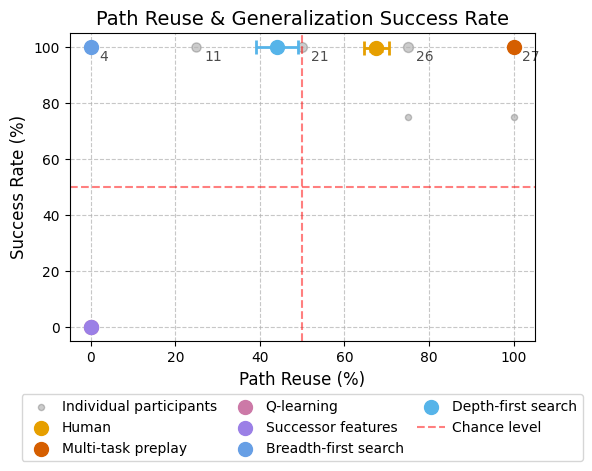

Filtered 0 rows with null success or reuse


Simulating data: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 17.03it/s]

Simulating data: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 18.97it/s]

Simulating data: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 17.91it/s]

Simulating data: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 23.62it/s]

Simulating data: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 21.00it/s]

Simulating data: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 21.33it/s]

Simulating data: 100%|██████████████████████████████

n no_reuse: 63
n reuse: 87


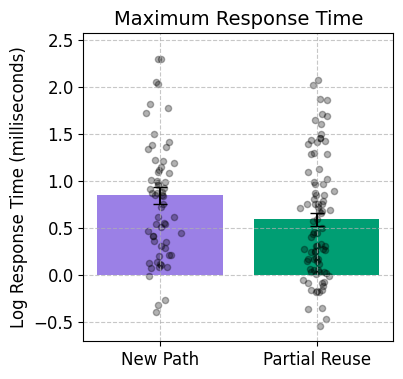

Experiment 1 Statistical Analysis


Analysis Results:
N = 91 participants (mean 4.0 trials per participant)
Mean reuse rate: 0.676 (SE: 0.030)

Normality Test (Shapiro-Wilk):
p = 0.000 (Non-normal distribution)

Wilcoxon signed-rank test:
statistic = 2052.500
p = 0.000

Effect Size (r):
0.513

Required Sample Sizes:
Power 80%: N ≥ 7 participants
Power 90%: N ≥ 8 participants
Power 95%: N ≥ 10 participants

Reaction Time Analysis

log_max_rt
--------------------

Linear Mixed Effects Model Results:
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: RT       
No. Observations: 362     Method:             REML     
No. Groups:       91      Scale:              0.2187   
Min. group size:  3       Log-Likelihood:     -327.7152
Max. group size:  4       Converged:          Yes      
Mean group size:  4.0                                  
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--

In [24]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"
save_dir = f"{data_dir}/housemaze_analysis_results_final/"
# %debug
housemaze_analysis.path_reuse_results(
  user_df,
  model_df,
  save_dir=save_dir,
  tell_reuse=1,
  display_figs=True,
  save_figs=True,
  n_simulations=1,
  verbosity=1,
)

In [57]:
# data_dir = '/Users/wilka/git/research/results/human_dyna/'
# save_dir = f'{data_dir}/analysis_results/'
# housemaze_analysis.experiment_1_results(
#     user_df,
#     model_df,
#     save_dir=save_dir,
#     tell_reuse=0,
#     display_figs=False,
#     save_figs=True)

In [15]:
# data_dir = "/Users/wilka/git/research/results/human_dyna/"
# save_dir = f"{data_dir}/housemaze_analysis_results_combined/"


# housemaze_analysis.experiment_2_results(
#   user_df,
#   model_df,
#   save_dir=save_dir,
#   tell_reuse=1,
#   save_figs=True,
#   verbosity=1,
# )
# # housemaze_analysis.experiment_2_results(
# #     user_df,
# #     model_df,
# #     save_dir=save_dir,
# #     tell_reuse=0,
# #     save_figs=True)

In [68]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"
save_dir = f"{data_dir}/housemaze_analysis_results_combined/"
# %debug
housemaze_analysis.experiment_3_results(
  user_df,
  model_df,
  filter_columns=[],
  save_dir=save_dir,
  tell_reuse=1,
  save_figs=True,
  verbosity=1,
)

No file specified for image dict.
Using: /Users/wilka/git/research/human-dyna-web/libraries/housemaze/housemaze/image_data.pkl
Experiment 3 Statistical Analysis


log_first_rt:
N = 25 participants
Mean difference = 0.276 (SE: 0.118)

Normality Test (Shapiro-Wilk):
p = 0.000 (Non-normal distribution)

Wilcoxon signed-rank test:
statistic = 215.000
p = 0.082

Effect Size (r):
0.278

Power Analysis:
Achieved power with current N=25: 0.834
Required sample sizes:
  80% power: N ≥ 21
  90% power: N ≥ 29
  95% power: N ≥ 36

log_avg_rt:
N = 25 participants
Mean difference = -0.015 (SE: 0.023)

Normality Test (Shapiro-Wilk):
p = 0.636 (Normal distribution)

Paired t-test:
statistic = -0.667
p = 0.744

Effect Size (Cohen's d):
-0.133

Power Analysis:
Achieved power with current N=25: 0.159
Required sample sizes:
  80% power: N ≥ 350
  90% power: N ≥ 484
  95% power: N ≥ 611



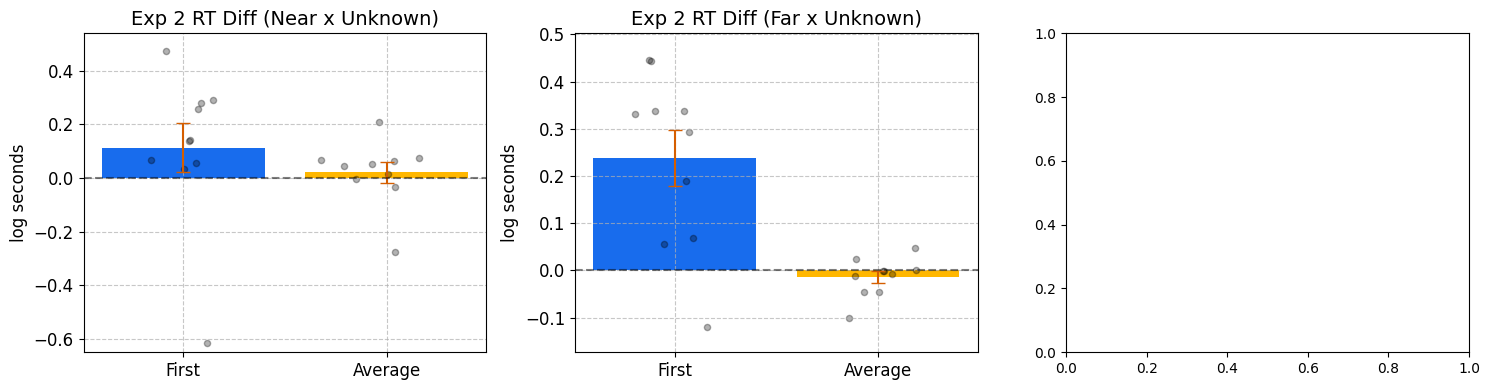

In [27]:
data_dir = "/Users/wilka/git/research/results/human_dyna/"
save_dir = f"{data_dir}/housemaze_analysis_results_combined/"
# %debug
housemaze_analysis.experiment_4_results(
  user_df,
  # model_df,
  save_dir=save_dir,
  filter_columns=[],
  save_figs=True,
  display_figs=True,
  tell_reuse_options=[0],
)